<a href="https://colab.research.google.com/github/Oktavian19/PCVK_Ganjil_2025/blob/main/Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection
Metode yang digunakan
1. Template Matching
2. Edge Detection
3. Corner Detection
4. Grid Detection
5. Contour Detection

In [38]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [39]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Template Matching

Menggunakan library openCV
**cv.matchTemplate()**, dengan parameter:
- **image**: citra input
- **templ**: template yang dicari, ukurannya tidak boleh lebih besar dari citra input
- **method**: metode dari template matching

Jenis metode template matching di OpenCV
1. TM_SODIFF
2. TM_SODIFF_NORMED
3. TM_CCORR
4. TM_CCORR_NORMED
5. TM_CCOEFF
6. TM_CCOEFF_NORMED

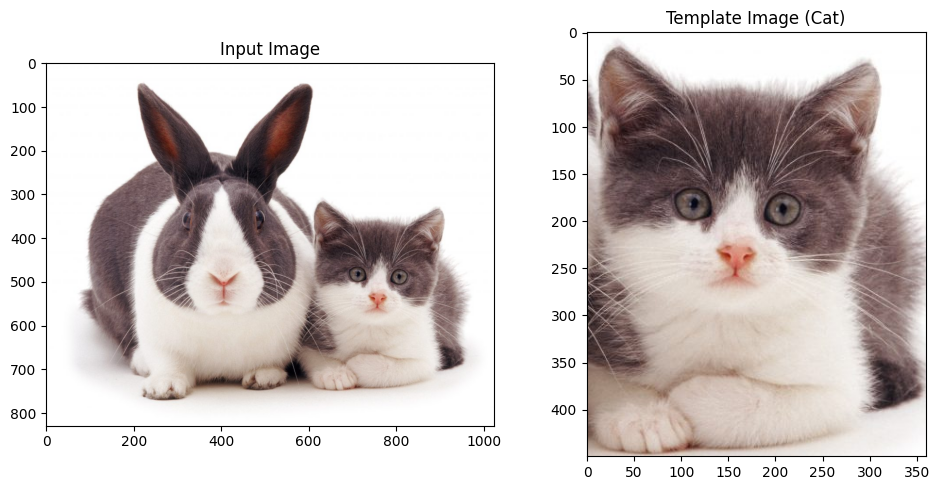

In [40]:
path = "/content/drive/MyDrive/asset/Images/Object Detection/cats_and_bunnies.jpg"
img = cv.imread(path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

templ = img[300:750, 600:960]
w, h, c = templ.shape

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(templ)
plt.title("Template Image (Cat)")

plt.tight_layout()
plt.show()

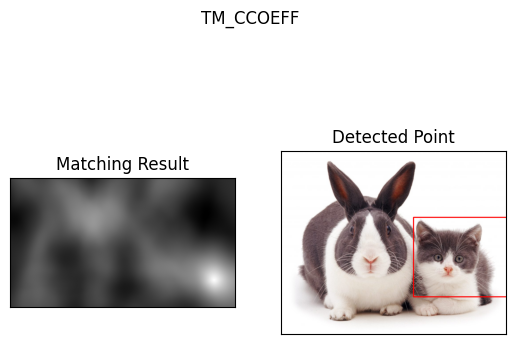

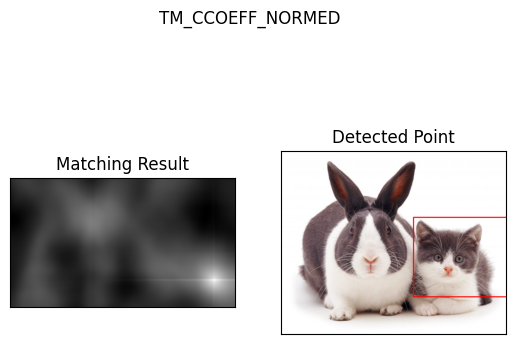

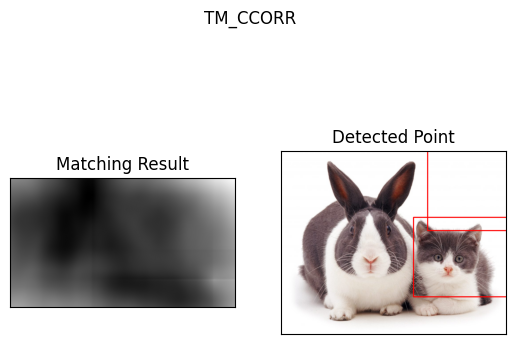

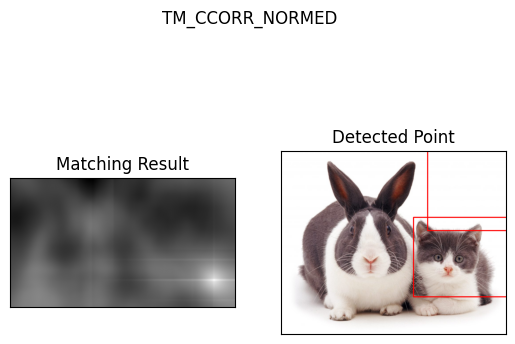

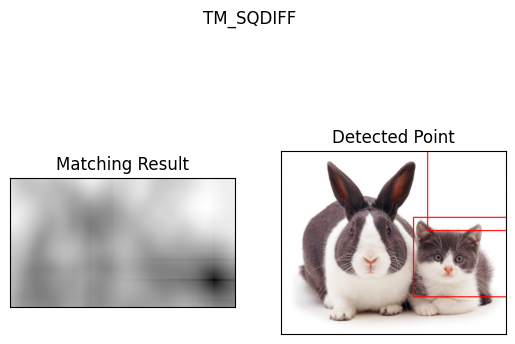

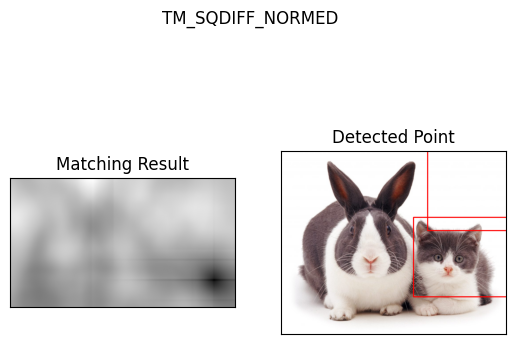

In [41]:
methods = ['TM_CCOEFF', 'TM_CCOEFF_NORMED', 'TM_CCORR',
            'TM_CCORR_NORMED', 'TM_SQDIFF', 'TM_SQDIFF_NORMED']

for meth in methods:
    method = getattr(cv, meth)

    # Apply template Matching
    res = cv.matchTemplate(img,templ,method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    # If the method is TM_SQDIFF or TM_SQDIFF_NORMED, take minimum
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)

    cv.rectangle(img,top_left, bottom_right, (255,0,0), 3)

    plt.subplot(121),plt.imshow(res,cmap = 'gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122),plt.imshow(img,cmap = 'gray')
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth)

    plt.show()

In [42]:
import numpy as np
from PIL import Image

def template_match(img, template, threshold=0.6, nms_threshold=0.3):
    """
    Template matching dengan Non-Maximum Suppression untuk menghindari deteksi ganda

    Parameters:
    - img: gambar input (2D numpy array)
    - template: template yang dicari (2D numpy array)
    - threshold: threshold korelasi (0-1)
    - nms_threshold: threshold untuk NMS (0-1)

    Returns:
    - List of dictionaries dengan informasi deteksi:
        [{'bbox': (x, y, w, h), 'score': correlation_score}, ...]
    """
    img_h, img_w = img.shape
    temp_h, temp_w = template.shape

    # Normalisasi template
    template_mean = np.mean(template)
    template_std = np.std(template)
    template_norm = (template - template_mean) / (template_std + 1e-8)

    results = []

    # Sliding window
    for y in range(0, img_h - temp_h, 2):  # Step 2 untuk mempercepat
        for x in range(0, img_w - temp_w, 2):
            window = img[y:y + temp_h, x:x + temp_w]

            # Skip window yang terlalu kecil atau std=0
            if window.size == 0 or np.std(window) < 1e-8:
                continue

            window_mean = np.mean(window)
            window_std = np.std(window)
            window_norm = (window - window_mean) / window_std

            # Hitung korelasi
            corr = np.mean(window_norm * template_norm)

            if corr >= threshold:
                results.append({
                    'bbox': (x, y, temp_w, temp_h),
                    'score': corr
                })

    # Apply Non-Maximum Suppression
    if results:
        results = non_max_suppression(results, nms_threshold)

    return results

def non_max_suppression(detections, threshold):
    """
    Non-Maximum Suppression untuk menghilangkan deteksi berlebih

    Parameters:
    - detections: list of dict dengan keys 'bbox' dan 'score'
    - threshold: threshold IoU untuk suppression

    Returns:
    - List deteksi setelah NMS
    """
    if len(detections) == 0:
        return []

    # Convert to numpy array untuk mempermudah processing
    boxes = np.array([d['bbox'] for d in detections])
    scores = np.array([d['score'] for d in detections])

    # Hitung area tiap bounding box
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 0] + boxes[:, 2]
    y2 = boxes[:, 1] + boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)

    # Urutkan berdasarkan score (descending)
    indices = np.argsort(scores)[::-1]

    keep = []
    while len(indices) > 0:
        current = indices[0]
        keep.append(current)

        if len(indices) == 1:
            break

        # Hitung IoU dengan semua box lainnya
        rest = indices[1:]

        xx1 = np.maximum(x1[current], x1[rest])
        yy1 = np.maximum(y1[current], y1[rest])
        xx2 = np.minimum(x2[current], x2[rest])
        yy2 = np.minimum(y2[current], y2[rest])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        intersection = w * h

        # IoU = intersection / (area1 + area2 - intersection)
        iou = intersection / (areas[current] + areas[rest] - intersection)

        # Hanya keep indices dengan IoU <= threshold
        indices = indices[1:][iou <= threshold]

    return [detections[i] for i in keep]

# Fungsi utilitas untuk visualisasi hasil
def visualize_detections(img, detections, output_path=None):
    """
    Visualisasi hasil deteksi pada gambar

    Parameters:
    - img: gambar asli (PIL Image atau numpy array)
    - detections: hasil dari template_match
    - output_path: path untuk menyimpan gambar (optional)
    """
    if isinstance(img, np.ndarray):
        img_display = Image.fromarray(img.astype(np.uint8))
    else:
        img_display = img.copy()

    # Convert ke RGB jika grayscale
    if img_display.mode != 'RGB':
        img_display = img_display.convert('RGB')

    # Draw bounding boxes
    from PIL import ImageDraw
    draw = ImageDraw.Draw(img_display)

    for i, detection in enumerate(detections):
        x, y, w, h = detection['bbox']
        score = detection['score']

        # Draw rectangle
        draw.rectangle([x, y, x + w, y + h], outline='red', width=2)

        # Draw score text
        draw.text((x, y - 10), f'Score: {score:.3f}', fill='red')

    if output_path:
        img_display.save(output_path)

    return img_display

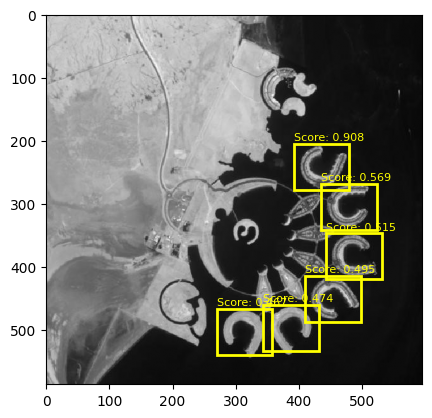

In [60]:
path = "/content/drive/MyDrive/asset/Images/Object Detection/bahrain.jpg"
template_path = "/content/drive/MyDrive/asset/Images/Object Detection/bahrain-template.jpg"


# === Load gambar ===
input_img = np.array(Image.open(path).convert("L"))
template_img = np.array(Image.open(template_path).convert("L"))

# === Jalankan matching ===
matches = template_match(input_img, template_img, threshold=0.45)

# === Visualisasi hasil ===
fig, ax = plt.subplots(1)
ax.imshow(input_img, cmap='gray')

for match in matches:
    x, y, w, h = match['bbox']
    score = match['score']

    # Pastikan koordinat integer
    x, y, w, h = int(x), int(y), int(w), int(h)

    rect = plt.Rectangle(
        (x, y), w, h,
        edgecolor='yellow', facecolor='none', linewidth=2
    )
    ax.add_patch(rect)

    # Tambahkan score
    ax.text(x, y - 5, f'Score: {score:.3f}', color='yellow', fontsize=8)


In [44]:
img = cv.imread('/content/drive/MyDrive/asset/Images/Object Detection/car-park.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

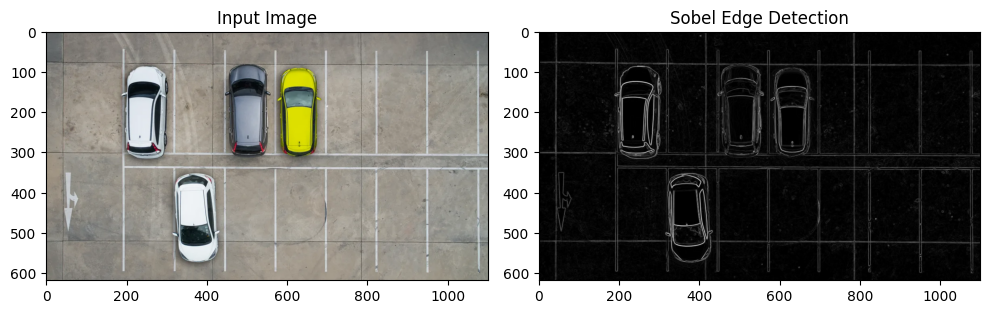

In [45]:
sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
sobel = cv.magnitude(sobelx, sobely)

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(sobel, cmap = "gray")
plt.title("Sobel Edge Detection")

plt.tight_layout()
plt.show()

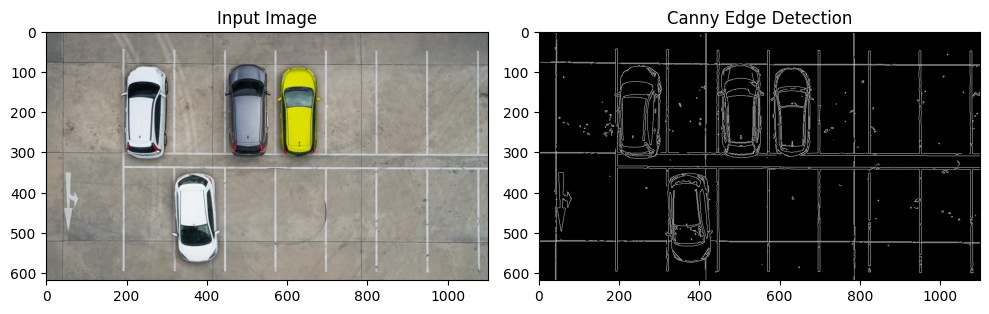

In [46]:
canny = cv.Canny(gray, 100, 200)

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(canny, cmap = "gray")
plt.title("Canny Edge Detection")

plt.tight_layout()
plt.show()

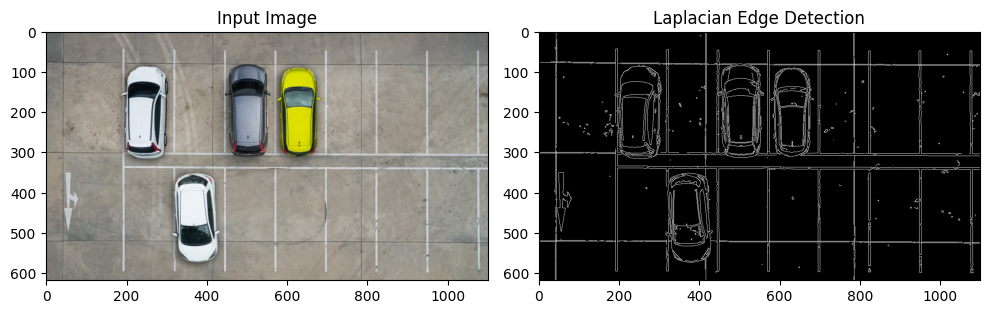

In [47]:
laplacian = cv.Laplacian(gray, cv.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(canny, cmap = "gray")
plt.title("Laplacian Edge Detection")

plt.tight_layout()
plt.show()

In [48]:
def corner_detection_comparison_advanced(image_path, harris_params=None, shi_tomasi_params=None):
    """
    Fungsi advanced untuk membandingkan Harris Corner dan Shi-Tomasi Detection

    Parameters:
    - image_path: path ke gambar
    - harris_params: dict parameter untuk Harris
    - shi_tomasi_params: dict parameter untuk Shi-Tomasi
    """

    # Default parameters
    if harris_params is None:
        harris_params = {'blockSize': 2, 'ksize': 3, 'k': 0.04, 'threshold': 0.01}

    if shi_tomasi_params is None:
        shi_tomasi_params = {'maxCorners': 100, 'qualityLevel': 0.01, 'minDistance': 10}

    # Baca gambar
    img = cv.imread(image_path)
    if img is None:
        print(f"Error: Tidak dapat membaca gambar dari {image_path}")
        return None, None

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Harris Corner Detection
    gray_harris = np.float32(gray)
    dst = cv.cornerHarris(gray_harris,
                          blockSize=harris_params['blockSize'],
                          ksize=harris_params['ksize'],
                          k=harris_params['k'])
    dst = cv.dilate(dst, None)

    img_harris = img.copy()
    thresh_harris = harris_params['threshold'] * dst.max()
    img_harris[dst > thresh_harris] = [0, 0, 255]

    # Shi-Tomasi Detection
    corners = cv.goodFeaturesToTrack(gray,
                                     maxCorners=shi_tomasi_params['maxCorners'],
                                     qualityLevel=shi_tomasi_params['qualityLevel'],
                                     minDistance=shi_tomasi_params['minDistance'])

    img_shi_tomasi = img.copy()
    if corners is not None:
        corners = corners.astype(int)
        for corner in corners:
            x, y = corner.ravel()
            cv.circle(img_shi_tomasi, (x, y), 3, [0, 255, 0], -1)

    return img_harris, img_shi_tomasi

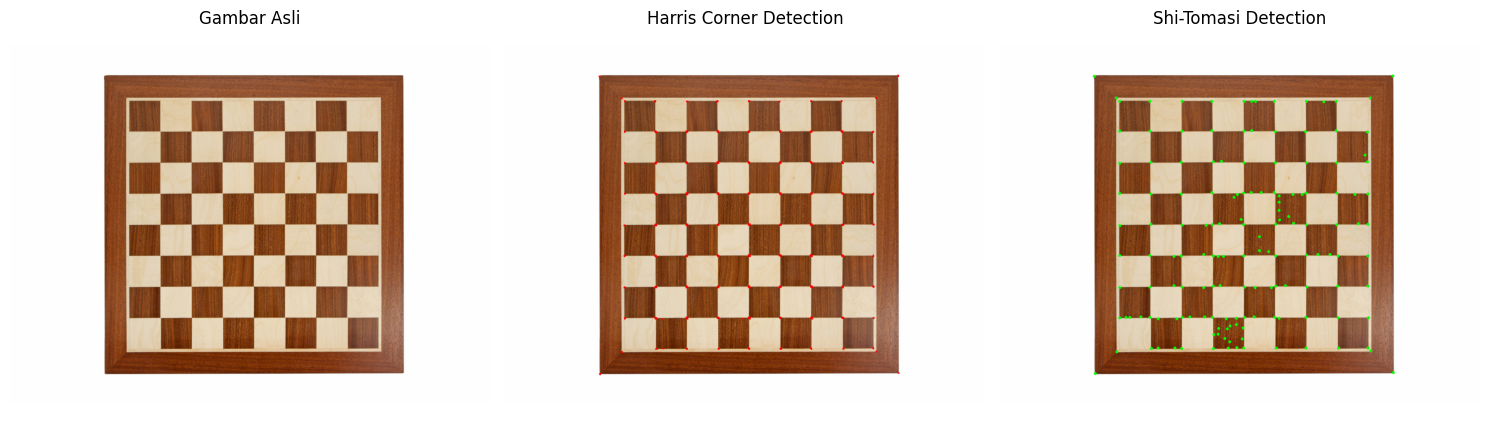

In [49]:
# Contoh penggunaan dengan parameter custom
path = '/content/drive/MyDrive/asset/Images/Object Detection/chess-board.jpg'
img = cv.imread(path)

# Custom parameters
harris_params = {'blockSize': 2, 'ksize': 3, 'k': 0.04, 'threshold': 0.01}
shi_tomasi_params = {'maxCorners': 150, 'qualityLevel': 0.01, 'minDistance': 8}

img_harris, img_shi_tomasi = corner_detection_comparison_advanced(
    path,
    harris_params=harris_params,
    shi_tomasi_params=shi_tomasi_params
)

# Visualisasi
plt.figure(figsize=(15, 5))

images = [
    (img, 'Gambar Asli'),
    (img_harris, 'Harris Corner Detection'),
    (img_shi_tomasi, 'Shi-Tomasi Detection')
]

for i, (image, title) in enumerate(images):
    plt.subplot(1, 3, i+1)
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

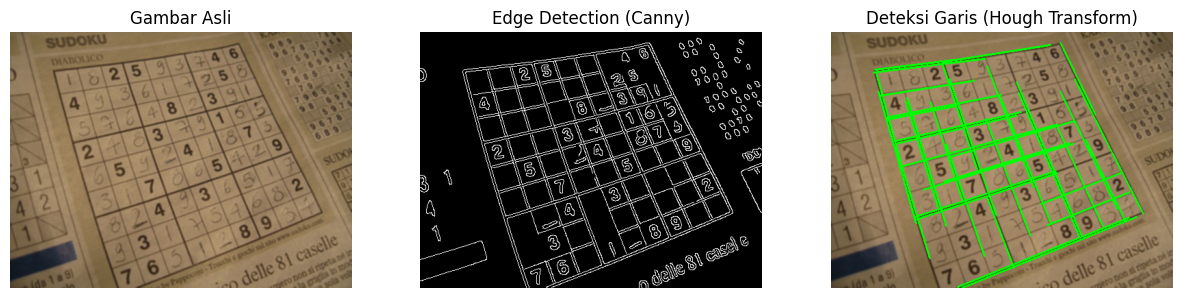

Jumlah garis terdeteksi: 38


In [50]:
path = "/content/drive/MyDrive/asset/Images/Object Detection/sudoku.jpg"
img = cv.imread(path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(gray, (5, 5), 0)

edges = cv.Canny(blur, 50, 150, apertureSize=3)

lines = cv.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=100,
    minLineLength=100,
    maxLineGap=10
)

img_lines = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Gambar Asli")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Edge Detection (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Deteksi Garis (Hough Transform)")
plt.imshow(cv.cvtColor(img_lines, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

if lines is not None:
    print(f"Jumlah garis terdeteksi: {len(lines)}")
else:
    print("Tidak ada garis terdeteksi.")


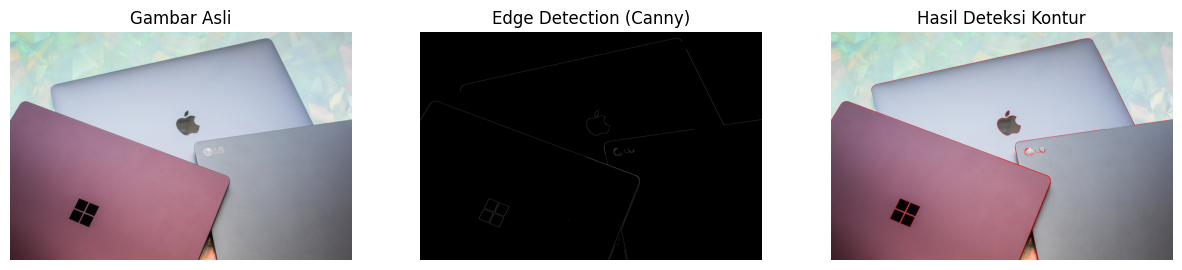

Jumlah kontur terdeteksi: 24


In [51]:
path = "/content/drive/MyDrive/asset/Images/Object Detection/laptop.jpg"
img = cv.imread(path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(gray, (5, 5), 0)
edges = cv.Canny(blur, 100, 200)

contours, hierarchy = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

img_contours = img.copy()
cv.drawContours(img_contours, contours, -1, (0, 0, 255), 2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Gambar Asli")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Edge Detection (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Hasil Deteksi Kontur")
plt.imshow(cv.cvtColor(img_contours, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

print(f"Jumlah kontur terdeteksi: {len(contours)}")


## Face Detection

In [52]:
cascade_wajah = cv.CascadeClassifier('/content/drive/MyDrive/asset/haarcascades/haarcascade_frontalface_alt.xml')

def face_detection(path):
    full_path = f'/content/drive/MyDrive/asset/Images/facedet/{path}'

    img = cv.imread(full_path)
    if img is None:
        print(f"Gagal membaca gambar: {full_path}")
        return

    roi_wajah = cascade_wajah.detectMultiScale(
        img,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (x, y, w, h) in roi_wajah:
        cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)

    plt.figure(figsize=(6, 6))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f"Hasil Deteksi")
    plt.axis("off")
    plt.show()

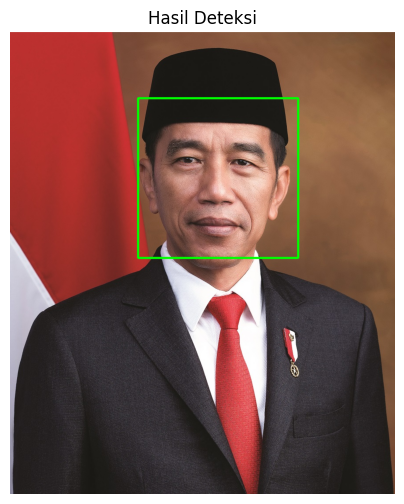

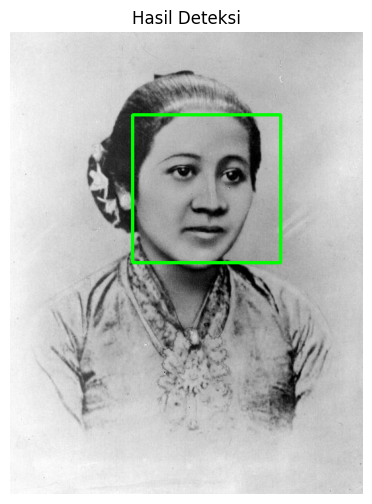

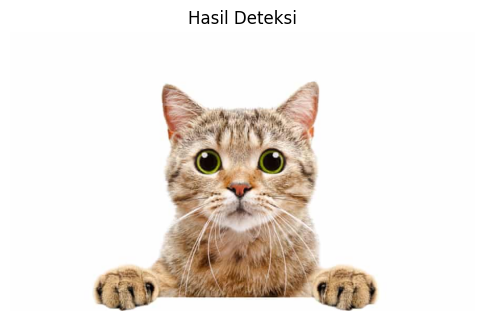

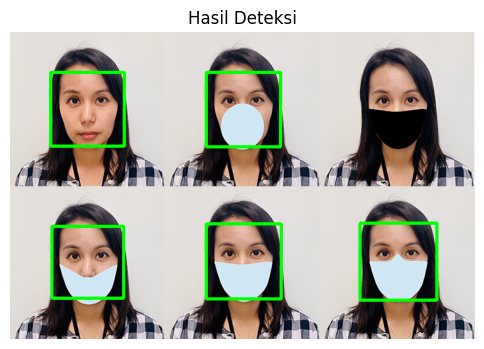

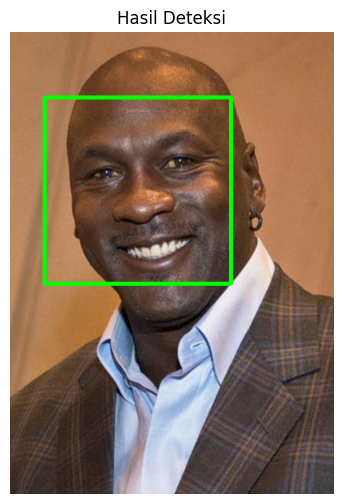

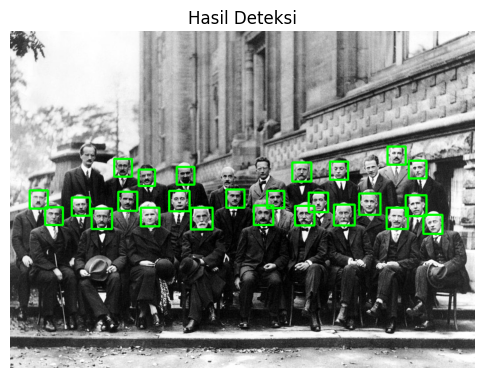

In [53]:
images = ["jokowi.jpg", "kartini.jpg", "kucing.jpg", "mask.png", "mjordan.jpg", "solvayconf.jpg"]

for img in images:
  face_detection(path=img)

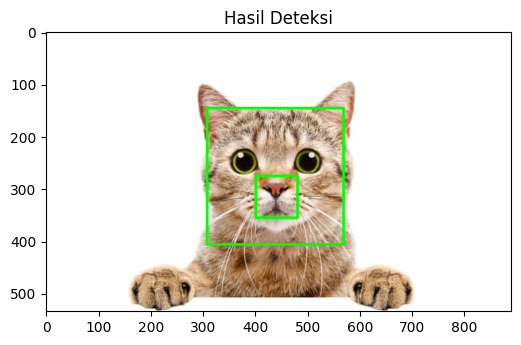

In [54]:
cascade_wajah = cv.CascadeClassifier('/content/drive/MyDrive/asset/haarcascades/haarcascade_frontalcatface.xml')

path = '/content/drive/MyDrive/asset/Images/facedet/kucing.jpg'

img = cv.imread(path)

roi_wajah = cascade_wajah.detectMultiScale(
    img,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

for (x, y, w, h) in roi_wajah:
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title(f"Hasil Deteksi")
plt.show()

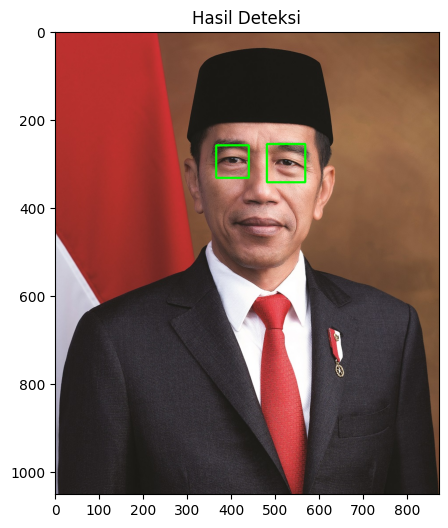

In [55]:
cascade_wajah = cv.CascadeClassifier('/content/drive/MyDrive/asset/haarcascades/haarcascade_eye.xml')

path = '/content/drive/MyDrive/asset/Images/facedet/jokowi.jpg'

img = cv.imread(path)

roi_wajah = cascade_wajah.detectMultiScale(
    img,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

for (x, y, w, h) in roi_wajah:
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title(f"Hasil Deteksi")
plt.show()

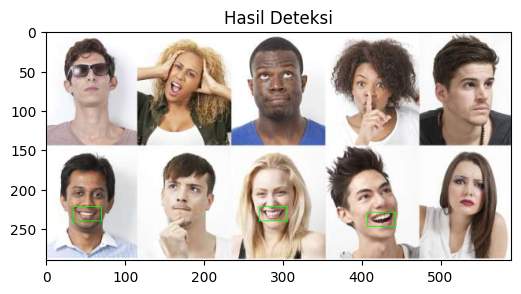

In [64]:
cascade_wajah = cv.CascadeClassifier('/content/drive/MyDrive/asset/Images/haarcascades/haarcascade_smile.xml')

path = '/content/drive/MyDrive/asset/people.png'

img = cv.imread(path)

roi_wajah = cascade_wajah.detectMultiScale(
    img,
    scaleFactor=1.3,
    minNeighbors=7,
    minSize=(5, 5)
)

for (x, y, w, h) in roi_wajah:
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 1)

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title(f"Hasil Deteksi")
plt.show()

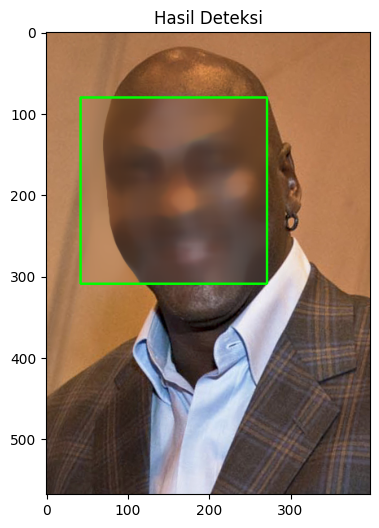

In [65]:
cascade_wajah = cv.CascadeClassifier('/content/drive/MyDrive/asset/haarcascades/haarcascade_frontalface_alt.xml')

path = '/content/drive/MyDrive/asset/Images/facedet/mjordan.jpg'

img = cv.imread(path)

roi_wajah = cascade_wajah.detectMultiScale(
    img,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

for (x, y, w, h) in roi_wajah:
    wajah = img[y:y+h, x:x+w]
    wajah_blur = cv.medianBlur(wajah, 35)
    img[y:y+h, x:x+w] = wajah_blur

    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title(f"Hasil Deteksi")
plt.show()

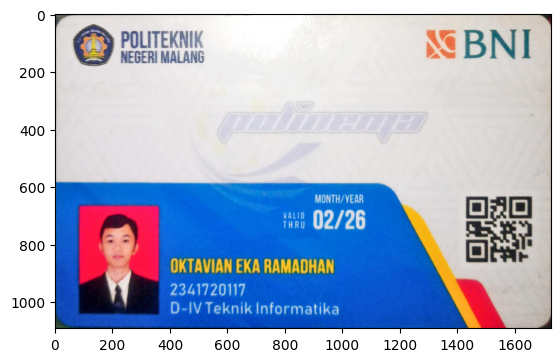

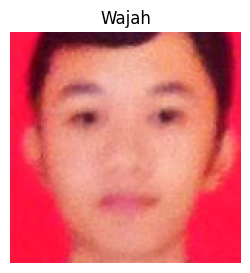

In [68]:
cascade_wajah = cv.CascadeClassifier('/content/drive/MyDrive/asset/haarcascades/haarcascade_frontalface_alt.xml')

full_path = '/content/drive/MyDrive/BERKAS PENTING/KTM.jpg'

img = cv.imread(full_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

roi_wajah = cascade_wajah.detectMultiScale(
    img,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

plt.imshow(img)

for i, (x, y, w, h) in enumerate(roi_wajah, start=1):
    wajah = img[y:y+h, x:x+w]

    plt.figure(figsize=(3, 3))
    plt.imshow(wajah)
    plt.title(f"Wajah")
    plt.axis("off")
    plt.show()